# Exploratory Data Analysis
<!-- 
## Time spent
|  Name  | Time   |
| ---    |  ---   |
| Danylo | 40 min |
| Ivan   | 5 min  |
| Daryna | 0 min  |
-->
## Plan (temporary)
Danylo - reddit and H1
Ivan & Daryna - kaggle

## Overview
Since our goal has some specifics, we will follow our own flow with exploration and analysis of data. To be exact, we already have our hypotheses and we will try to find approaches in order to prove those hypothese right, or wrong. We will not follow guidelines or try to check any boxes, instead we will follow our curiosity and play until we have the answer.

However, there is one guideline: before freestyling with analysis, explore the data and brainstorm what visualizations should be made.

### Hypotheses
- H1: Discourse is getting shorter and simpler
    - Lexical & NLP approach
    - Temporal/Behavioral aspect
- H2: Short-form platforms accelerated the degradation of discourse
- H3: Wellbeing is getting worse among doomscrollers
- H4: Crises intensify doomscrolling and negativity

### Additional approches
- questionnaire
- YouTube comments

## H1: Discourse is getting shorter and simpler
>Only Danylo works below
Time spent: 60min

In [2]:
# placeholder

## H3 probably
> Only Darka works below
Time spent: 5 min

## H4 probably
> Only Ivan works below
Time spent: 0 min

First, i need to define what actuall datasets i can use for checking this hypothesis(YT trending videos, reddit comments, GDELT events, idk still). Then figure out how to process them, and compare so that this hypothesis is verifyable.

I'll start by what datasets i can and want to use.

---
### H4 analysis: code and data
Code: `src/figs_crisis.py` (charts), `src/events.py` (event study, placebo test, change-points) and `src/textmining.py` (per-comment tone and crisis-word features). Every chart is listed in `docs/figure_index.md`, every script is explained in `docs/code_guide.md`, and the numbers quoted below are reproduced by `src/checks.py`.

**Data used here.** Six subreddits (r/memes, r/teenagers, r/books, r/explainlikeimfive, r/todayilearned, r/nosurf), January 2012 to September 2026, from Arctic Shift. The raw files are a random time-slot sample (about 10k comments per subreddit-month), except r/nosurf, which is complete. Cleaned comments only: bots, moderator messages, templated text, removed text and spam are dropped (`src/io_reddit.py`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from src.viz import set_style, GROUP_COLORS, SUB_COLORS, ACCENT, GRAY, save, finding_title, caption, event_line, highlight_vs_gray
from src.config import AGG, EXT, EVENTS, GROUPS
set_style()

## Design of the H4 analysis
**Question.** Do crises intensify negativity and doomscrolling-like behaviour? Reddit records posting, not reading, so "doomscrolling" can only be proxied (talk about it, and patterns of active posting). Claims stay at community level: no statement about individuals or clinical mood.

**Events inside the data range** (dates checked on 2026-10-04 against news and reference sources): the WHO declares COVID-19 a pandemic (11 March 2020), the full-scale Russian invasion of Ukraine (24 February 2022), the Hamas attack on Israel that starts the Gaza war (7 October 2023), and the assassination of Charlie Kirk (10 September 2025). The last one was not on our first list: it showed up as the busiest r/nosurf day (11 September 2025: 530 comments, 2.8 times the month before; three threads carried 72% of the day, the two biggest about the killing).

**Communities.** Short-form (r/memes + r/teenagers), long-form (r/books + r/explainlikeimfive), baseline (r/todayilearned) and r/nosurf. **No news subreddits are in the data yet** (r/worldnews and r/news were planned), so this is only the half of the design that asks whether non-news communities react; we cannot yet show that news communities react more.

**Statistic.** For each event and community, the change in an outcome between the 8 weeks before the event (days -56 to -1) and the 4 weeks after (days 0 to 27), computed as a ratio of sums over all comments in the window. **Placebo test:** the same statistic at 400 random fake dates (never within 120 days of a real event); `p` is the share of fake dates with an equally large or larger absolute change. We use this instead of a textbook standard error because the data are time-slot samples (about 10-15 slots a month in the big subreddits), so day-to-day values are sparse and autocorrelated.

**Outcomes.** Mean VADER compound score (tone), words about the event itself (to check the event reached the community), crisis words in general, and `doomscroll*` mentions per 10,000 words. VADER is a word list; it has not yet been compared with hand-labeled comments (a 100-comment file is ready for the team in `data/processed/derived/`).

**Not done.** Emotion categories (fear, anger, sadness, planned C25): the NRC lexicon is not available offline. US anxiety/depression indicators from the CDC (planned optional C30). News subreddits (see above).

### Q1. Do crises show up in what people write?
**Why we asked:** An effect on tone only makes sense if the crisis was part of the conversation.

**What we did:** Monthly rate of a broad list of crisis words (war, pandemic, covid, lockdown, invasion, Ukraine, Gaza, Hamas, Israel, Palestine, genocide, terror, shooting, assassination, crisis, recession, famine, refugees, earthquake, hurricane) per 10,000 words, per subreddit, 3-month mean; the four events are dashed lines. Months with under 50,000 words are dropped.

**Result:** r/memes shows one clear crisis peak: 34 crisis words per 10,000 words in March 2022, 4.1 times its monthly median (8.2). The other communities have no common peak: r/teenagers peaks in July 2026 (18.2, median 4.2), r/books in December 2025 (12.3, median 5.9), r/todayilearned in August 2022 (18.4, median 11.6), r/nosurf in December 2020 (6.8, median 3.1) and r/explainlikeimfive in October 2012 (14.8, median 5.4).

**Interpretation:** Only r/memes reacts strongly in the broad measure. Words like war, crisis or shooting appear in games, history, books and jokes all the time, so the broad list is noisy. The event-specific words in Q2 are the cleaner check.

**Next question:** Did each event actually reach each community (Q2)?

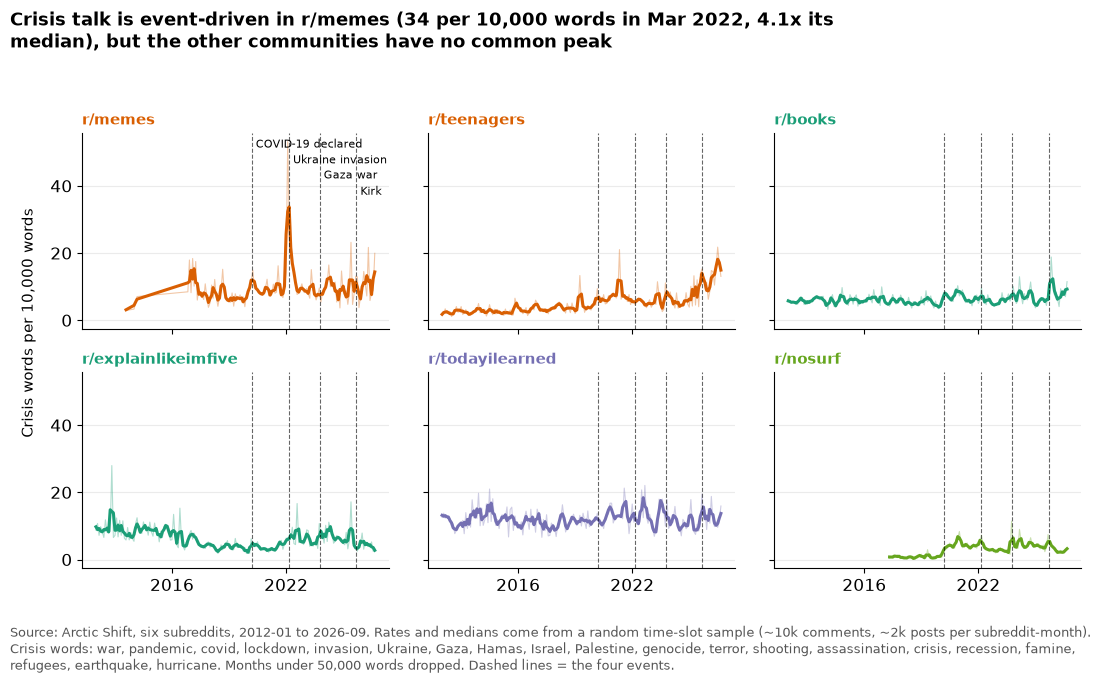

In [2]:
from src import figs_crisis as figs
_ = figs.c20()
plt.show()

**Code for C20:** `src/figs_crisis.py` function `c20()`; reads `daily_features`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q2. Did each event reach each community?
**Why we asked:** If an event leaves no trace in a community's vocabulary, finding no change in tone there says little.

**What we did:** Weekly rate of event-specific words (covid/pandemic/lockdown; Ukraine/Russia/Putin/invasion; Gaza/Hamas/Israel/Palestine; Kirk/Turning Point/assassination) in event time, as change versus the 8 weeks before. The gray band marks the four weeks used in the test. Four community groups, four events.

**Result:** Event words rose in 13 of 16 community-event pairs (p < 0.05 against random dates). Short-form: +8.2 (COVID), +56.4 (Ukraine), +5.6 (Gaza), +4.1 (Kirk) per 10,000 words. Long-form: +4.6, +2.1, +3.9, +2.0. r/nosurf: +6.3, +5.0, +5.0, +5.2. r/todayilearned reacted to COVID (+4.0) but not to the other three (+0.4, -0.6, +0.3).

**Interpretation:** All three conversational communities noticed all four events; the Ukraine invasion dominated r/memes and r/teenagers. r/todayilearned, a feed of facts, is the exception, so it is a useful low-exposure comparison. This is the manipulation check for the tests that follow.

**Next question:** Did tone change with the attention (Q3)?

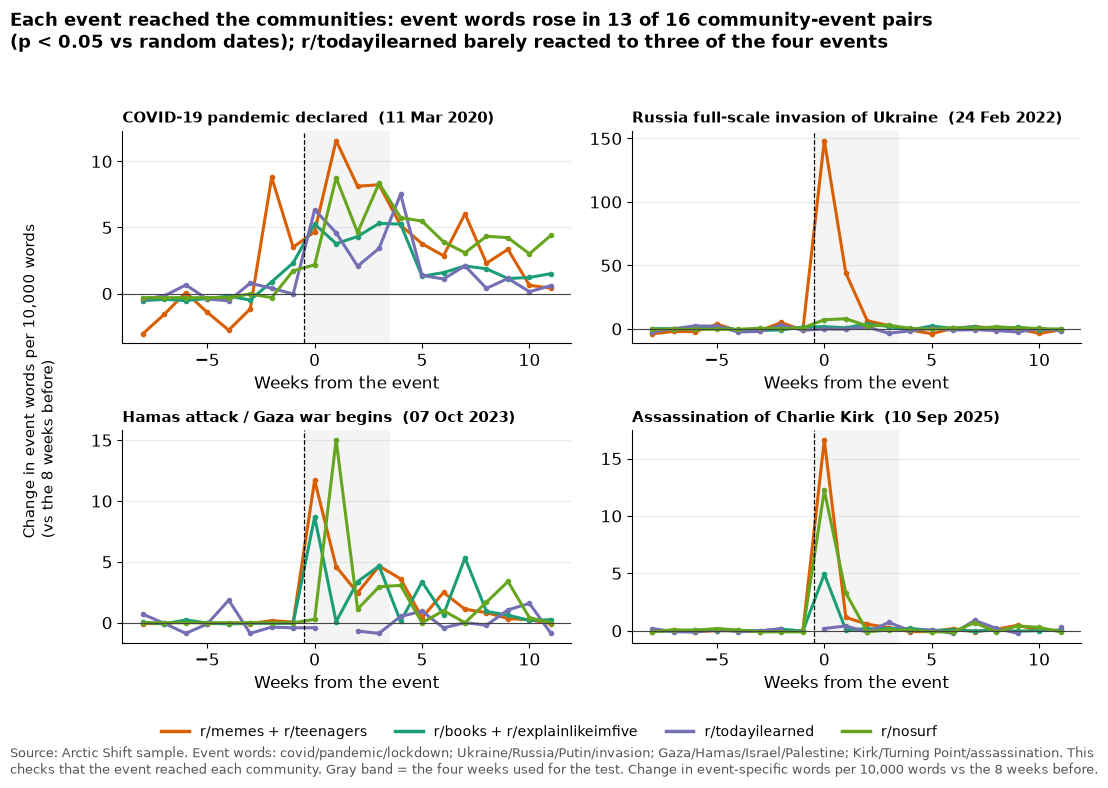

In [3]:
from src import figs_crisis as figs
_ = figs.c20b()
plt.show()

**Code for C20b:** `src/figs_crisis.py` function `c20b()`; reads `daily_features`, `event_effects`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

In [4]:
eff = pd.read_parquet(AGG / "event_effects.parquet")
t = eff[eff.outcome == "sentiment"].assign(cell=lambda d: d.effect.map("{:+.3f}".format) + "  (p=" + d.p.map("{:.2f}".format) + ")")
t.pivot(index="group", columns="event", values="cell").loc[["short_form", "long_form", "baseline", "reflective"]]

event,Assassination of Charlie Kirk,COVID-19 pandemic declared,Hamas attack / Gaza war begins,Russia full-scale invasion of Ukraine
group,,,,
short_form,-0.010 (p=0.32),+0.008 (p=0.44),-0.004 (p=0.71),-0.016 (p=0.15)
long_form,-0.013 (p=0.55),+0.007 (p=0.72),-0.027 (p=0.18),-0.038 (p=0.07)
baseline,-0.000 (p=1.00),+0.019 (p=0.27),-0.001 (p=0.96),-0.044 (p=0.04)
reflective,-0.053 (p=0.03),-0.037 (p=0.18),-0.049 (p=0.04),-0.015 (p=0.57)


### Q3. Did tone get more negative after the events? (H4)
**Why we asked:** H4: crises intensify negativity. The core signal is spillover into communities that are not about news.

**What we did:** Weekly mean VADER compound score in event time (week 0 = days 0-6), as change versus the 8 weeks before, for four community groups and four events (table above gives the 4-week change and the placebo p-value for each pair).

**Result:** After the three violent events (Ukraine, Gaza, Kirk) tone was lower than before in 11 of the 12 community-event pairs (the twelfth, r/todayilearned after Kirk, is zero), by up to 0.05 compound points. The largest drops are in r/nosurf (Kirk -0.053, Gaza -0.050), r/todayilearned (Ukraine -0.044) and long-form (Ukraine -0.038). After the COVID declaration tone rose slightly in three groups (+0.007 to +0.019) and fell in r/nosurf (-0.037).

**Interpretation:** The direction is fairly consistent for violent events but the sizes are small: for scale, r/nosurf's mean tone fell by 0.20 over nine years (0.36 in 2017, 0.16 in 2026). The weekly lines are noisy, mostly because each week rests on a few time slots. Whether the dips exceed chance is tested in Q8.

**Next question:** Is the dip larger than a random month would produce (Q8)? And does talk about doomscrolling rise (Q4)?

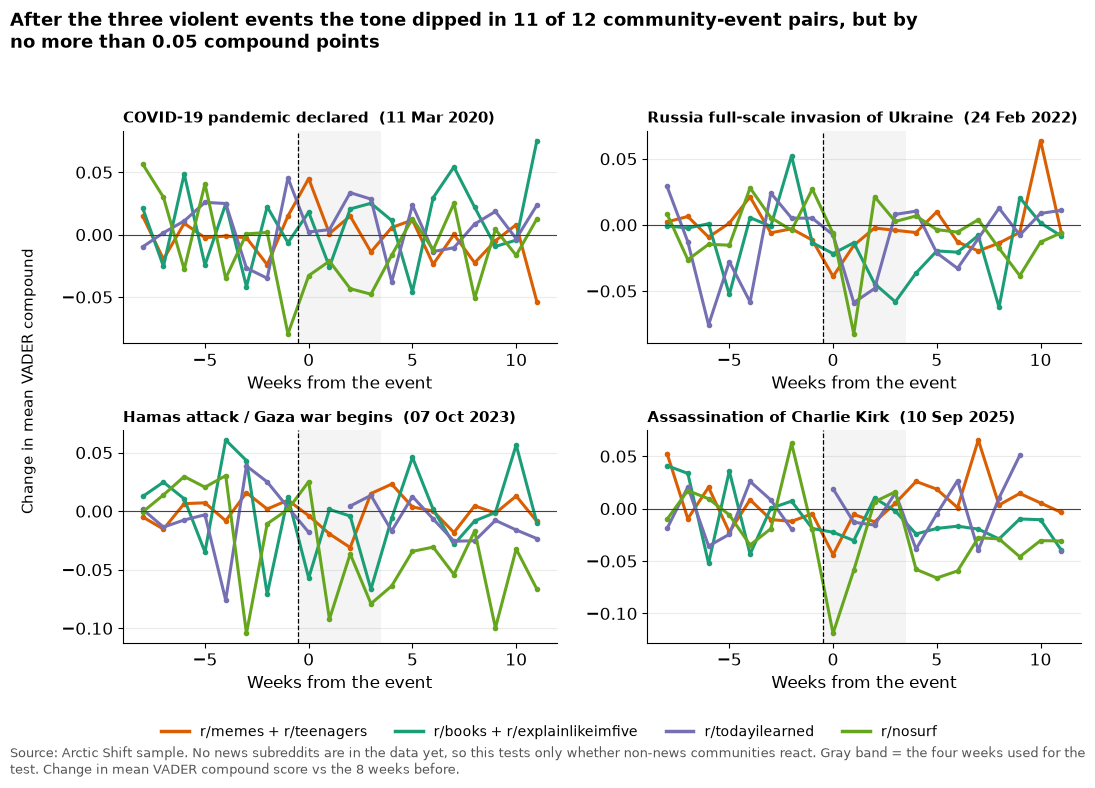

In [5]:
from src import figs_crisis as figs
_ = figs.c21()
plt.show()

**Code for C21:** `src/figs_crisis.py` function `c21()`; reads `daily_features`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q4. Did talk about doomscrolling rise after the events?
**Why we asked:** The doomscrolling half of H4: if crises push people to scroll, they might also talk about it.

**What we did:** Weekly `doomscroll*` and `doom surf*` mentions per 10,000 words in event time, as change versus the 8 weeks before. r/nosurf is the only community that uses the word often (about 1.6 per 10,000 words); the other five are pooled in gray.

**Result:** Four-week changes in r/nosurf: COVID 0.0 (p = 1.0), Ukraine +0.8 (p = 0.05), Gaza +0.5 (p = 0.16), Kirk -0.3 (p = 0.28), against a placebo spread of about 0.3. The pooled other communities stay near zero.

**Interpretation:** No clear rise. The Ukraine invasion is the only borderline case, and it is one of four tests. Counting mentions measures talk about doomscrolling, not scrolling; lurking is invisible.

**Next question:** Does the daily rhythm of posting change (Q5)?

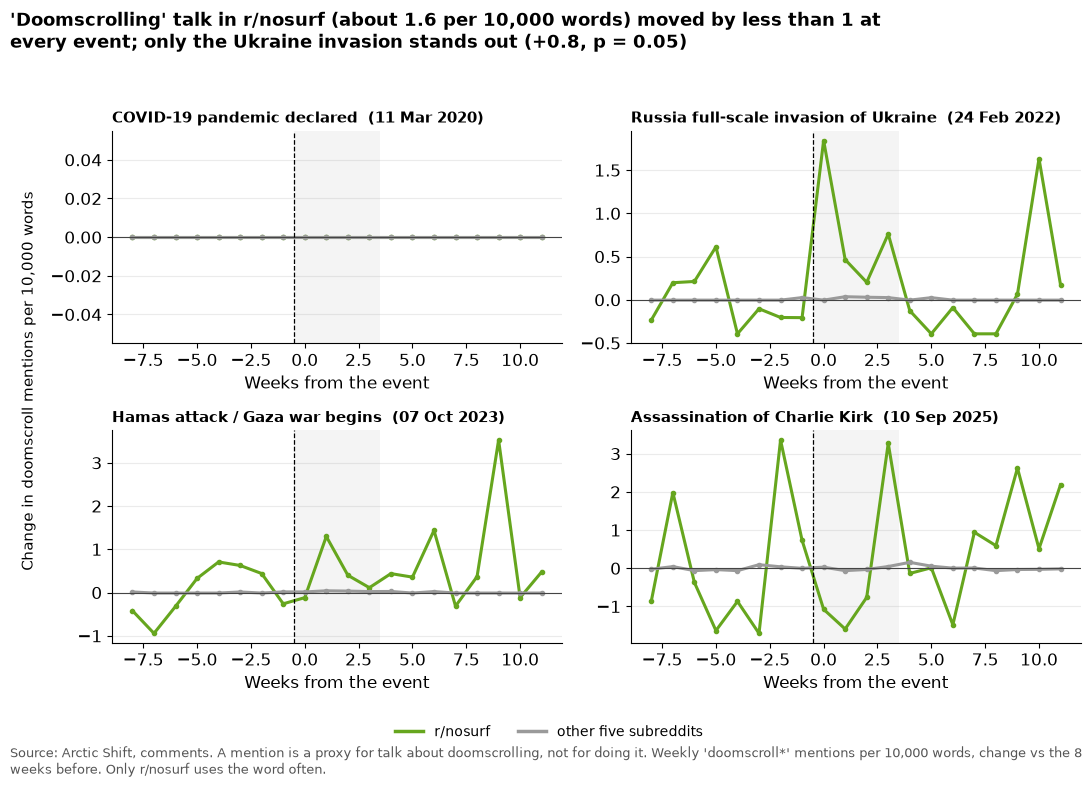

In [6]:
from src import figs_crisis as figs
_ = figs.c22()
plt.show()

**Code for C22:** `src/figs_crisis.py` function `c22()`; reads `daily_features`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q5. Did r/nosurf's daily rhythm change after the events?
**Why we asked:** Doomscrolling is often described as late-night behaviour; a shift in when people post would be a behavioural trace.

**What we did:** Share of r/nosurf comments by UTC weekday and hour in the 4 weeks after minus the 8 weeks before (percentage points), diverging palette centered on zero, smoothed over 3 hours. r/nosurf only: it is the only community with every comment, so cells are not distorted by sampling. As a yardstick we computed the largest cell difference at 150 random fake dates.

**Result:** The largest single-cell shifts are 0.56 percentage points (COVID), 0.50 (Ukraine), 0.37 (Gaza) and 0.77 (Kirk). Ninety-five percent of random fake dates produce a largest shift below 0.82, so none of the four events moves the rhythm more than a random date does. The strongest cells for the Kirk event fall on the event day and the day after, when the busiest r/nosurf day (11 September 2025) happened.

**Interpretation:** No evidence of a changed daily rhythm; the post window of four weeks holds only about 3,000-6,000 comments, so cells are noisy and only large shifts could show.

**Next question:** Do posting sessions get longer (Q6)?

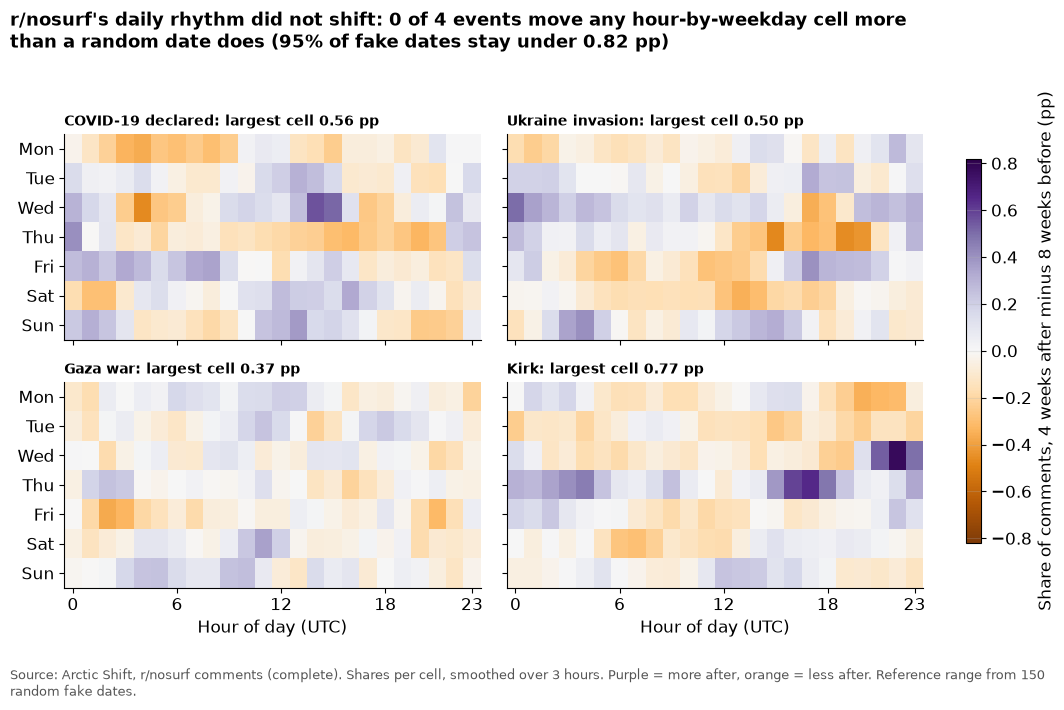

In [7]:
from src import figs_crisis as figs
_ = figs.c23()
plt.show()

**Code for C23:** `src/figs_crisis.py` function `c23()`; reads `per-comment features (data/processed/derived)`; built by `python run_pipeline.py features`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q6. Did posting sessions in r/nosurf get longer?
**Why we asked:** Longer unbroken stretches of activity are the closest thing to a scrolling session that posting data can show.

**What we did:** Gap-based sessions (messages by one author with gaps of at most 30 minutes) from comments and submissions, r/nosurf only; empirical cumulative distribution of the length of sessions with 2 or more messages, 8 weeks before versus 4 weeks after.

**Result:** The share of sessions with two or more messages is 11.5% vs 11.4% (COVID), 13.9% vs 11.9% (Ukraine), 12.5% vs 13.3% (Gaza) and 17.0% vs 16.0% (Kirk). Their median length is 6 vs 6 minutes, 6 vs 9, 6 vs 7 and 6 vs 6.

**Interpretation:** No change. This only sees active posting; reading without posting is invisible, so a real change in scrolling time could not show here.

**Next question:** Do the same people change (Q7)?

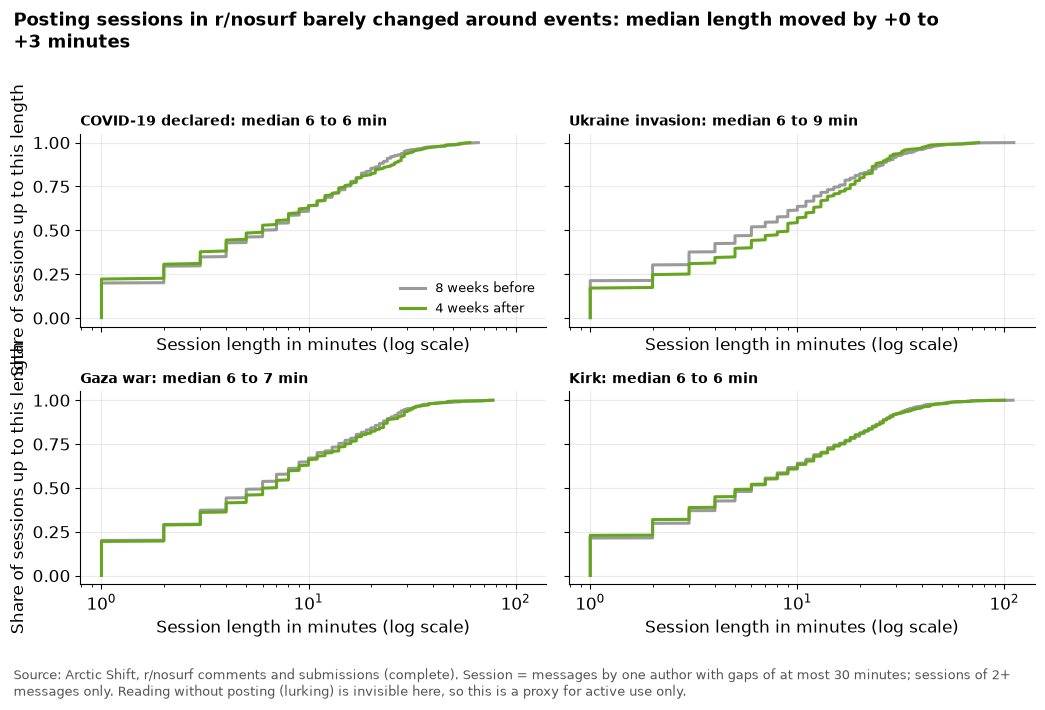

In [8]:
from src import figs_crisis as figs
_ = figs.c24()
plt.show()

**Code for C24:** `src/figs_crisis.py` function `c24()`; reads `processed Parquet (data/processed)`; built by `python run_pipeline.py clean`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q7. Do the same r/nosurf authors write differently after an event?
**Why we asked:** A change in average tone could come from different people posting; following the same authors removes that.

**What we did:** Authors with comments in both windows (8 weeks before, 4 weeks after): mean change in their VADER score, 95% bootstrap interval over authors, and the 95% range of the same statistic at 120 random fake dates (gray band).

**Result:** The same authors wrote less positively after all four events: -0.037 (COVID, 322 authors), -0.042 (Ukraine, 401), -0.058 (Gaza, 385), -0.070 (Kirk, 613). The intervals of Gaza and Kirk exclude zero; only the Kirk change lies outside the random-date band (-0.063 to +0.058).

**Interpretation:** A consistent small negative shift among people who keep posting, in the one community where we see everyone. But random dates also produce shifts of this size, and the topic of the week (people discussing the news in their own words) changes the vocabulary VADER reads, so this is tone of the text, not mood of the people.

**Next question:** Is the whole pattern distinguishable from chance (Q8)?

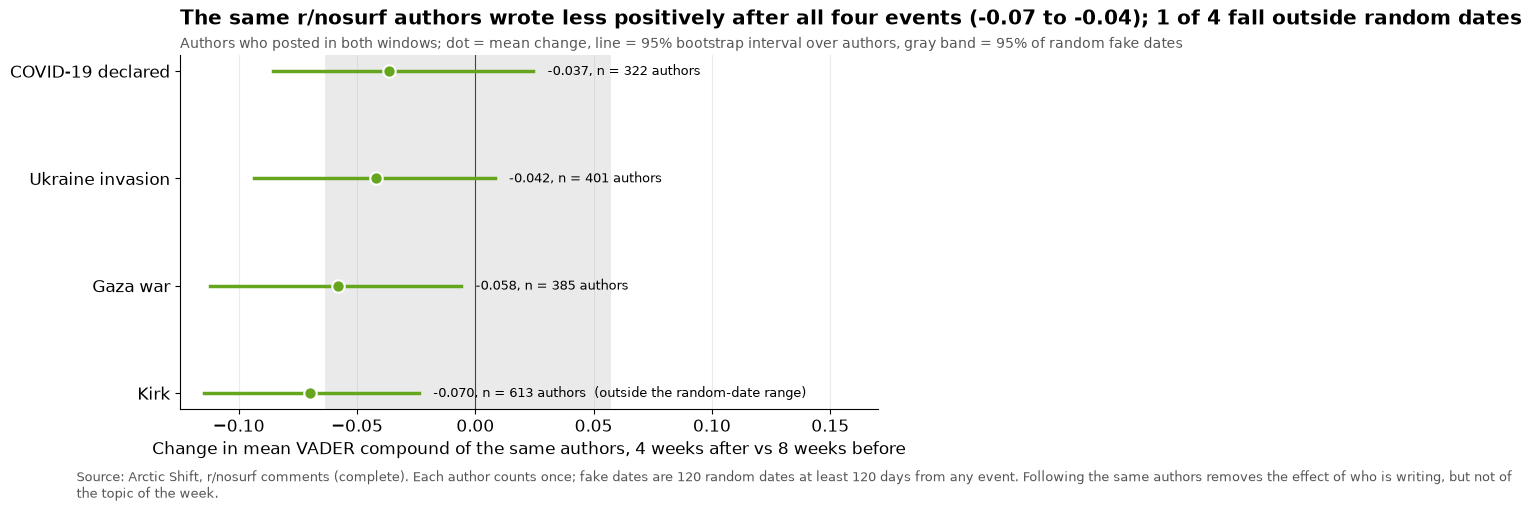

In [9]:
from src import figs_crisis as figs
_ = figs.c26()
plt.show()

**Code for C26:** `src/figs_crisis.py` function `c26()`; reads `per-comment features (data/processed/derived)`; built by `python run_pipeline.py features`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q8. Is the dip real? (placebo test)
**Why we asked:** A dip means little unless random dates show nothing like it.

**What we did:** For short-form and r/nosurf: histogram of the change in mean tone at 400 random fake dates (gray) with the real event as a colored line and its p-value. Across all four groups and four events (16 tests) we count the p-values below 0.05.

**Result:** Three of 16 tests fall outside the random range: r/nosurf after Gaza (p = 0.04) and after Kirk (p = 0.03), and r/todayilearned after Ukraine (p = 0.04). Short-form p-values are 0.44, 0.15, 0.71 and 0.32. By chance 0.8 of 16 would be expected.

**Interpretation:** Weak, not nothing: if the 16 tests were independent, three or more significant would happen about 4% of the time by chance. They are not independent (the same weeks and communities recur), and we ran many tests, so we do not call it a finding. What we can say: any effect of these events on tone is small and, for most communities, indistinguishable from the weekly noise.

**Next question:** Is uncertainty in the world, as a continuous measure, related to tone (Q9)?

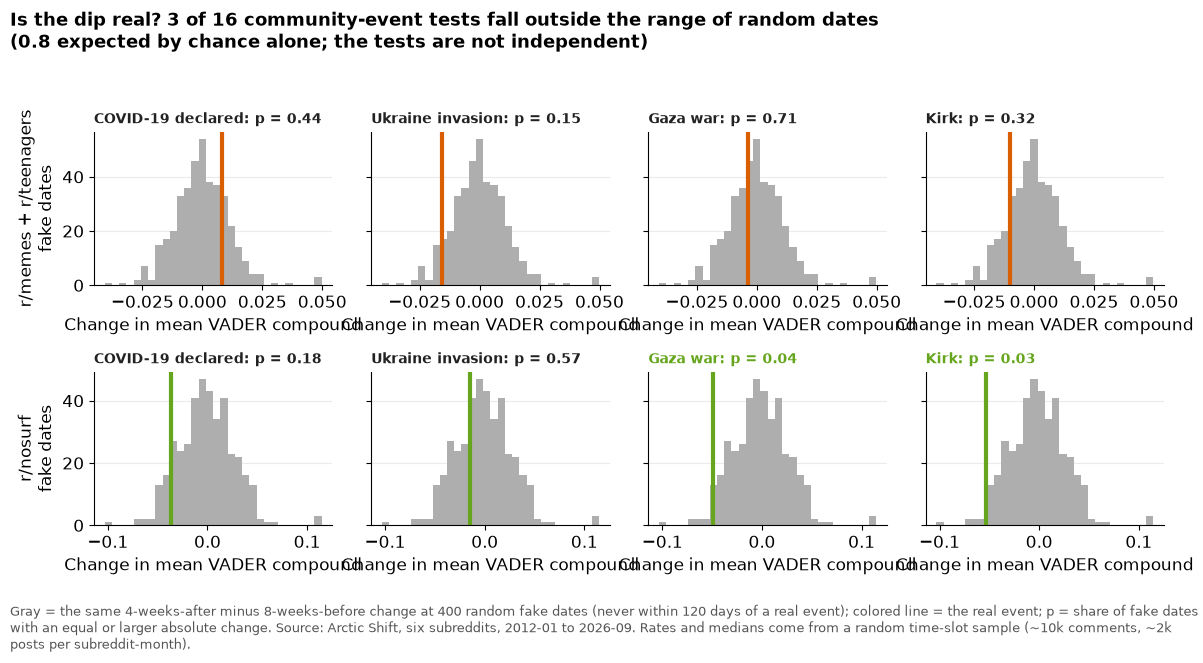

In [10]:
from src import figs_crisis as figs
_ = figs.c27()
plt.show()

**Code for C27:** `src/figs_crisis.py` function `c27()`; reads `daily_features`, `event_effects`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q9. Does world uncertainty lead or follow tone and crisis talk?
**Why we asked:** Four events are few; a continuous crisis-intensity series uses all 160 months.

**What we did:** Cross-correlation, at lags of -6 to +6 months, between monthly changes in the World Uncertainty Index (global, GDP-weighted; Ahir, Bloom and Furceri) and monthly changes in mean tone or crisis-word rate, per community group (2013-2026). Both series are first-differenced so that shared long-run trends do not create correlation. Gray band = approximate 95% range for no relation.

**Result:** Nothing reliable: the largest absolute correlation is 0.19 against a noise band of +/-0.15, and the same-month correlation between uncertainty and crisis words is between -0.09 and +0.08 in all groups.

**Interpretation:** Monthly changes in global uncertainty are unrelated to changes in tone or crisis wording in these communities. The index is global and dominated by large economies, and our crisis words are broad, so a null here does not rule out reactions to specific events.

**Next question:** Did tone shift at other moments (Q10)?

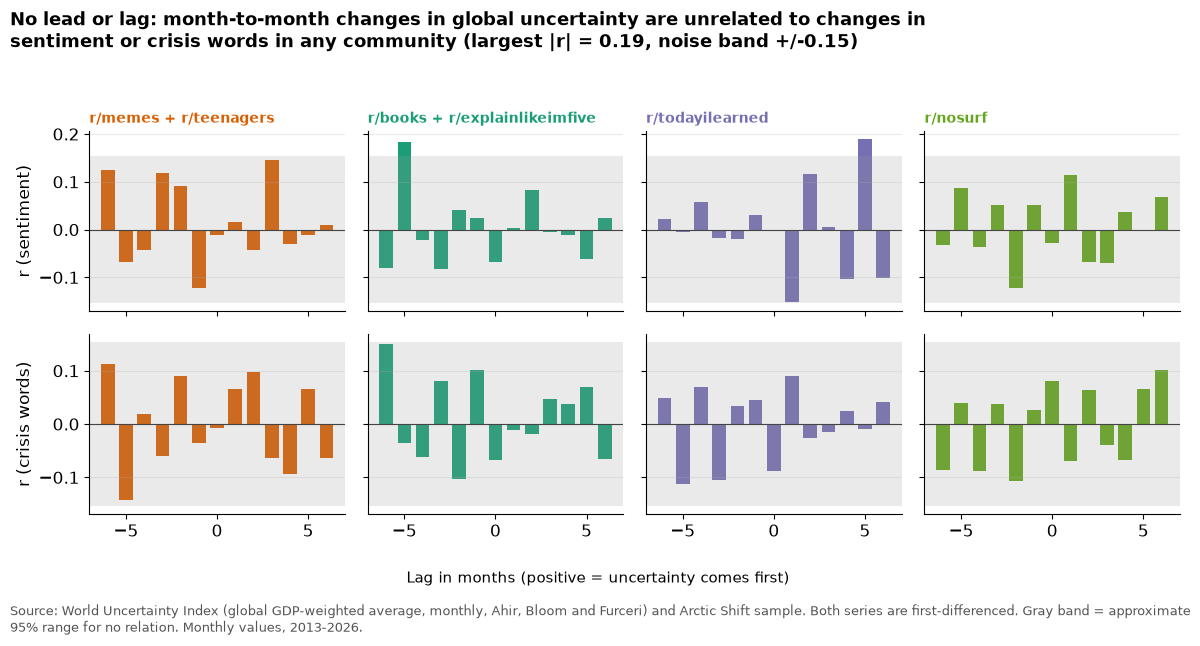

In [11]:
from src import figs_crisis as figs
_ = figs.c28()
plt.show()

**Code for C28:** `src/figs_crisis.py` function `c28()`; reads `daily_features`, `wui_monthly`; built by `python run_pipeline.py events, validate`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

### Q10. When did tone shift, and does it line up with the events?
**Why we asked:** A model-free check: find the breaks in each community's tone and see whether the four events are near them.

**What we did:** Change-point detection (PELT, least-squares cost, penalty from the noise of month-to-month differences) on the monthly mean VADER score of each subreddit; breaks drawn as dotted lines, events as dashed lines, step lines show the mean between breaks.

**Result:** 17 change-points in total (r/teenagers 6, r/nosurf 4, r/books 3, r/explainlikeimfive 2, r/memes 1, r/todayilearned 1). One falls within three months of an event: r/nosurf in December 2023, two months after the Hamas attack. Chance alone would put about 3 there.

**Interpretation:** Tone shifts in these communities follow slow changes (new users, moderation, platform changes), not the crisis dates. This is consistent with Q8 and with the long drift of tone in r/nosurf (mean score 0.36 in 2017, 0.16 in 2026): the drift over many years is much larger than any event effect we can detect.

**Next question:** What would settle H4? News subreddits as a contrast group and a hand-checked sentiment measure.

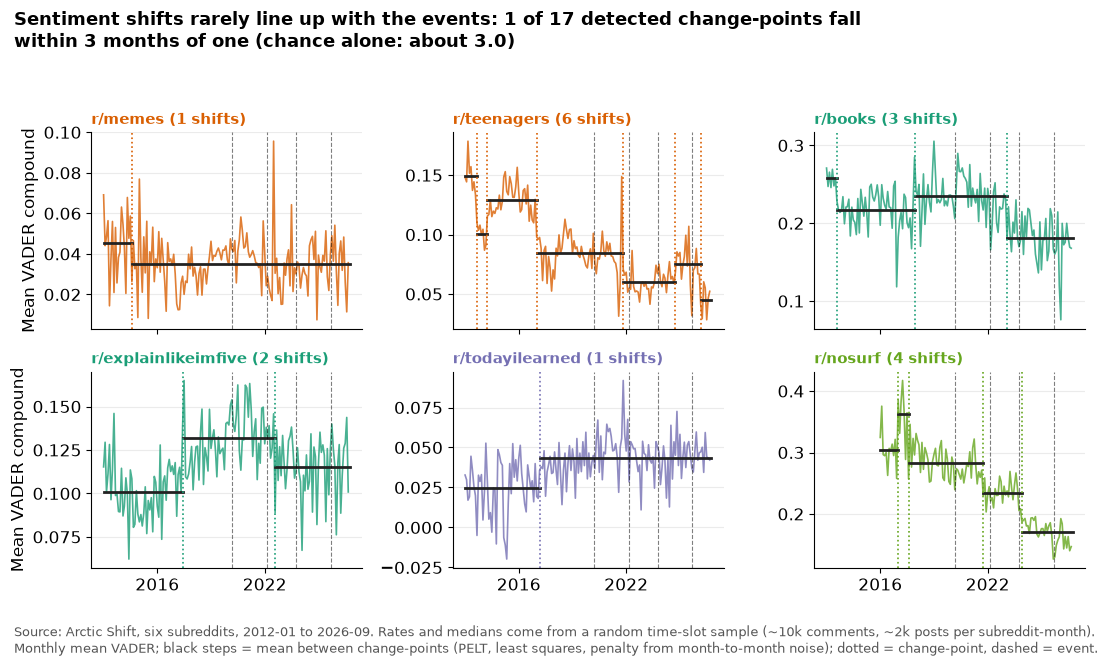

In [12]:
from src import figs_crisis as figs
_ = figs.c29()
plt.show()

**Code for C29:** `src/figs_crisis.py` function `c29()`; reads `daily_features`; built by `python run_pipeline.py events`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.

## What H4 shows
- **Events reach the communities.** Event words rose in 13 of 16 community-event pairs; r/todayilearned is the exception (Q2).
- **Tone: small, consistent direction, weak evidence.** Tone was lower after the three violent events in 11 of 12 pairs, by at most 0.05; three of 16 tests are outside the placebo range, about what we would expect by chance given many correlated tests (Q3, Q8). The same r/nosurf authors wrote 0.04-0.07 less positively afterwards, only Kirk beyond random dates (Q7).
- **Doomscrolling proxies: nothing.** Talk about doomscrolling, daily rhythm and session length of r/nosurf did not change beyond random variation (Q4-Q6).
- **No link to a continuous uncertainty index** and no change-points at the event dates (Q9, Q10).
- **Not yet tested:** the news-subreddit contrast, which is the cleanest way to separate "the crisis" from general drift; hand-validated sentiment.